In [ ]:
# !uv add matplotlib

In [4]:
import platform
import matplotlib.pyplot as plt

# OS에 따른 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')    # 맥: 애플 고딕
else:
    plt.rc('font', family='NanumBarunGothic') # 리눅스

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

# 결측 처리 전략 선택

| 조건               | 추천 방법                         |
| ---------------- | ----------------------------- |
| 결측 비율이 5% 미만     | 해당 행 삭제                       |
| 수치형 변수, 정규 분포 형태 | 평균 또는 중앙값                     |
| 범주형 변수, 불균형한 분포  | 최빈값 또는 Unknown                |
| 결측률 높고 중요 변수     | 예측 기반 보간(KNN 등)               |
| 머신러닝 모델용 입력      | SimpleImputer / KNNImputer 사용 |


# 누락 데이터 처리 (Missing Data Handling)

| 처리 방식       | 설명                   | 적용 조건/주의사항                 |
| ----------- | -------------------- | -------------------------- |
| 제거(drop)    | 결측치가 포함된 행 또는 열 삭제   | 결측치가 소수이고 삭제해도 정보 손실이 작을 때 |
| 대체(fill)    | 평균, 중앙값, 최빈값 등으로 채움  | 수치형 또는 범주형에 따라 적절히 선택      |
| 예측 기반 보간    | KNN, 회귀모델 등으로 결측값 예측 | 데이터 수가 충분하고 패턴이 명확할 때      |
| 특이값(모델로 처리) | 결측값 자체를 하나의 카테고리로 취급 | 트리 기반 모델 등에서는 효과적          |


## 데이터 생성

In [5]:
import pandas as pd

# 예제 데이터
data = {
    'date': pd.date_range(start='2024-01-01', periods=5),
    'age': [25, 30, None, 22, 28],
    'gender': ['M', None, 'F', 'F', 'M'],
    'bmi': [23.5, 27.8, 30.2, None, 24.1],
    'temperature': [22.5, None,  23.0, None, 21.8]
}
df = pd.DataFrame(data)
print(df)

        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
1 2024-01-02  30.0    NaN  27.8          NaN
2 2024-01-03   NaN      F  30.2         23.0
3 2024-01-04  22.0      F   NaN          NaN
4 2024-01-05  28.0      M  24.1         21.8


누락 데이터 확인
 - 수치로 확인
 - 그래프로 확인

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         5 non-null      datetime64[us]
 1   age          4 non-null      float64       
 2   gender       4 non-null      str           
 3   bmi          4 non-null      float64       
 4   temperature  3 non-null      float64       
dtypes: datetime64[us](1), float64(3), str(1)
memory usage: 332.0 bytes


In [10]:
# 누락 데이터 개수 확인
#print(df.isnull())   # null이 있으면 True, 관측값이 있으면 False
print(df.isnull().sum())

#누락 데이터 비율 확인
print(df.isnull().mean())

# 관측값 확인
print(df.notnull()) # 관측값이 있으면 True, null이면 False


date           0
age            1
gender         1
bmi            1
temperature    2
dtype: int64
date           0.0
age            0.2
gender         0.2
bmi            0.2
temperature    0.4
dtype: float64
   date    age  gender    bmi  temperature
0  True   True    True   True         True
1  True   True   False   True        False
2  True  False    True   True         True
3  True   True    True  False        False
4  True   True    True   True         True


In [11]:
#!uv add missingno

In [7]:
# !uv pip list | grep missingno
!uv pip list | findstr missingno

zsh:1: command not found: findstr


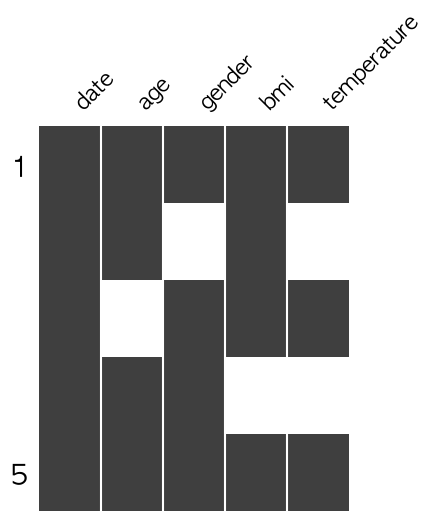

In [8]:
import missingno as msno

# 결측값 매트릭트 형태로 시각화
msno.matrix(df, figsize=(4,5), sparkline=False)
plt.show()

# 검은색: 관측 데이터
# 흰색 : 결측 데이터

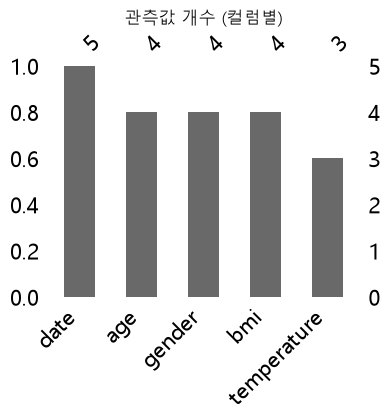

In [16]:
# 컬럼별 결측치 개수 시각화
msno.bar(df, figsize=(4,3))
plt.title("관측값 개수 (컬럼별)")
plt.show()

# 검은색: 관측값 데이터
# 위쪽 수치는 non-null 개수

c:\sk-encoa\data-collection-workspace\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


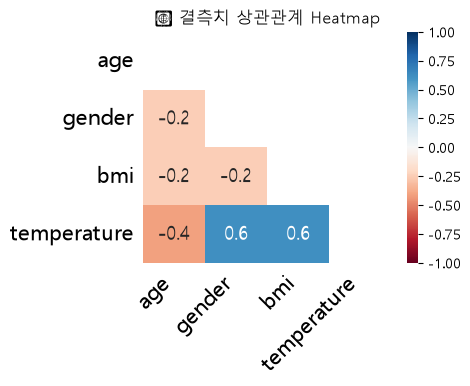

In [17]:
# 결측치 간 상관관계 분석
msno.heatmap(df, figsize=(4,3))
plt.title("🔥 결측치 상관관계 Heatmap")
plt.show()

# NaN이 같이 발생하는 정도 (null-null correlation) 를 나타냄.
# 1에 가까우면 같은 행에서 동시에 결측이 많이 발생한다는 의미.

c:\sk-encoa\data-collection-workspace\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127794 (\N{EVERGREEN TREE}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


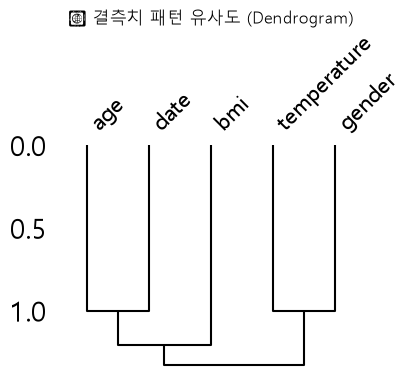

In [18]:
# 결측치 컬럼 간 유사도 계층 구조
msno.dendrogram(df, figsize=(4,3))
plt.title("🌲 결측치 패턴 유사도 (Dendrogram)")
plt.show()

# 결측 패턴이 유사한 변수끼리 묶어주는 트리 형태 시각화
# 데이터가 클수록 더 유용함

## 누락 데이터

| 조건                       | 추천 방식               |
| ------------------------ | ------------------- |
| 연속된 NaN이 많은 경우           | 평균, 예측 기반 고려        |
| 순서가 중요하지 않은 경우           | 다른 방식(평균, 중앙값 등) 선호 |
| 센서/시계열 데이터               | `ffill` or `bfill`  |
| 정해진 순서가 있는 데이터 (예: 타임라인) | `ffill`, `bfill`    |

In [21]:
df_1 = df.copy()
print(df_1)

# ① 수치형은 평균, 중앙값으로 대체
df_1['age'] = df_1['age'].fillna(df_1['age'].mean())   # 평균 대체
df_1['bmi'] = df_1['bmi'].fillna(df_1['bmi'].median()) # 중앙값 대체


# ② 범주형은 최빈값으로 대체
df_1['gender'] = df_1['gender'].fillna(df_1['gender'].mode()[0])
df_1

        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
1 2024-01-02  30.0    NaN  27.8          NaN
2 2024-01-03   NaN      F  30.2         23.0
3 2024-01-04  22.0      F   NaN          NaN
4 2024-01-05  28.0      M  24.1         21.8


,date,age,gender,bmi,temperature
0,2024-01-01,25.00,M,23.50,22.5
1,2024-01-02,30.00,F,27.80,NaN
2,2024-01-03,26.25,F,30.20,23.0
3,2024-01-04,22.00,F,25.95,NaN
4,2024-01-05,28.00,M,24.10,21.8


In [22]:
df_2 = df.copy()
print(df_2)

# ③ 앞의 값으로 채우기 (forward fill)
#df_ffill = df_2.fillna(method='ffill')  # deprecated
#df_ffill
df_ffill = df_2.ffill()
print("\nForward Fill 처리:")
print(df_ffill)

df_3 = df.copy()
# ④ 뒤의 값으로 채우기 (backward fill)
#df_bfill = df_3.fillna(method='bfill')
df_bfill = df_3.bfill()
print("\nBackward Fill 처리:")
print(df_bfill)


        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
1 2024-01-02  30.0    NaN  27.8          NaN
2 2024-01-03   NaN      F  30.2         23.0
3 2024-01-04  22.0      F   NaN          NaN
4 2024-01-05  28.0      M  24.1         21.8

Forward Fill 처리:
        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
1 2024-01-02  30.0      M  27.8         22.5
2 2024-01-03  30.0      F  30.2         23.0
3 2024-01-04  22.0      F  30.2         23.0
4 2024-01-05  28.0      M  24.1         21.8

Backward Fill 처리:
        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
1 2024-01-02  30.0      F  27.8         23.0
2 2024-01-03  22.0      F  30.2         23.0
3 2024-01-04  22.0      F  24.1         21.8
4 2024-01-05  28.0      M  24.1         21.8


In [ ]:
!uv add scikit-learn

In [13]:
from sklearn.impute import KNNImputer

df_4 = df.copy()
print(df_4.info())
print(df)

# 수치형 변수만 선택
numeric_df = df_4[['age', 'bmi']]

# ⑤ KNN 기반 대체 (k=2)
imputer = KNNImputer(n_neighbors=2)
df_knn = pd.DataFrame(imputer.fit_transform(numeric_df), columns=numeric_df.columns)
print(df_knn)

# 원래 df_4에 다시 대입
# 원래 df에 다시 대입
df_4[['age', 'bmi']] = df_knn
df_4


<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         5 non-null      datetime64[us]
 1   age          4 non-null      float64       
 2   gender       4 non-null      str           
 3   bmi          4 non-null      float64       
 4   temperature  3 non-null      float64       
dtypes: datetime64[us](1), float64(3), str(1)
memory usage: 332.0 bytes
None
        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
1 2024-01-02  30.0    NaN  27.8          NaN
2 2024-01-03   NaN      F  30.2         23.0
3 2024-01-04  22.0      F   NaN          NaN
4 2024-01-05  28.0      M  24.1         21.8
    age   bmi
0  25.0  23.5
1  30.0  27.8
2  29.0  30.2
3  22.0  23.8
4  28.0  24.1


,date,age,gender,bmi,temperature
0,2024-01-01,25.0,M,23.5,22.5
1,2024-01-02,30.0,NaN,27.8,NaN
2,2024-01-03,29.0,F,30.2,23.0
3,2024-01-04,22.0,F,23.8,NaN
4,2024-01-05,28.0,M,24.1,21.8


In [14]:
import numpy as np

df_5 = df.copy()
print(df_5)

# 수치형 컬럼만 추출
numeric_cols = df_5.select_dtypes(include=[np.number])

# 선형 보간으로 누락값 채우기 (시간 흐름을 고려함)
df_linear = numeric_cols.interpolate(method='linear')
df_linear

        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
1 2024-01-02  30.0    NaN  27.8          NaN
2 2024-01-03   NaN      F  30.2         23.0
3 2024-01-04  22.0      F   NaN          NaN
4 2024-01-05  28.0      M  24.1         21.8


,age,bmi,temperature
0,25.0,23.50,22.50
1,30.0,27.80,22.75
2,26.0,30.20,23.00
3,22.0,27.15,22.40
4,28.0,24.10,21.80


In [15]:
df_6 = df.copy()
print(df_6)

# method='time' 은 시계열(time series) 보간 방식은 인덱스가 DatetimeIndex일 때만 작동한다.
# 'date'를 인덱스로 설정
df_6  = df_6.set_index('date')

# 수치형 컬럼만 추출
numeric_cols = df_6.select_dtypes(include=[np.number])

# 시간 간격 고려한 보간 (예: 센서 데이터)
df_time = numeric_cols.interpolate(method='time')
df_time

        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
1 2024-01-02  30.0    NaN  27.8          NaN
2 2024-01-03   NaN      F  30.2         23.0
3 2024-01-04  22.0      F   NaN          NaN
4 2024-01-05  28.0      M  24.1         21.8


,age,bmi,temperature
date,,,
2024-01-01,25.0,23.50,22.50
2024-01-02,30.0,27.80,22.75
2024-01-03,26.0,30.20,23.00
2024-01-04,22.0,27.15,22.40
2024-01-05,28.0,24.10,21.80


## 누락 데이터 제거

In [ ]:
df_7 = df.copy()
print(df_7)

# ① 결측치가 포함된 행 제거
df_drop_rows = df_7.dropna()   # df_7.dropna(inplace=True)
print(df_drop_rows)
print(df_7)

df_7.dropna(inplace=True)
print(df_7)

        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
1 2024-01-02  30.0   None  27.8          NaN
2 2024-01-03   NaN      F  30.2         23.0
3 2024-01-04  22.0      F   NaN          NaN
4 2024-01-05  28.0      M  24.1         21.8
        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
4 2024-01-05  28.0      M  24.1         21.8
        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
1 2024-01-02  30.0   None  27.8          NaN
2 2024-01-03   NaN      F  30.2         23.0
3 2024-01-04  22.0      F   NaN          NaN
4 2024-01-05  28.0      M  24.1         21.8
        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
4 2024-01-05  28.0      M  24.1         21.8


In [ ]:
df_8 = df.copy()
print(df_8)

# ② 특정 열만 제거
df_drop_column = df_8.drop(columns=['gender'])  #  df_8.drop(columns=['gender'], inplace=True)
print(df_drop_column)
print(df_8)

df_8.drop(columns=['gender'], inplace=True)
print(df_8)

        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
1 2024-01-02  30.0   None  27.8          NaN
2 2024-01-03   NaN      F  30.2         23.0
3 2024-01-04  22.0      F   NaN          NaN
4 2024-01-05  28.0      M  24.1         21.8
        date   age   bmi  temperature
0 2024-01-01  25.0  23.5         22.5
1 2024-01-02  30.0  27.8          NaN
2 2024-01-03   NaN  30.2         23.0
3 2024-01-04  22.0   NaN          NaN
4 2024-01-05  28.0  24.1         21.8
        date   age gender   bmi  temperature
0 2024-01-01  25.0      M  23.5         22.5
1 2024-01-02  30.0   None  27.8          NaN
2 2024-01-03   NaN      F  30.2         23.0
3 2024-01-04  22.0      F   NaN          NaN
4 2024-01-05  28.0      M  24.1         21.8
        date   age   bmi  temperature
0 2024-01-01  25.0  23.5         22.5
1 2024-01-02  30.0  27.8          NaN
2 2024-01-03   NaN  30.2         23.0
3 2024-01-04  22.0   NaN          NaN
4 2024-01-05  28.0  24.1         21.8


## 중복데이터 제거
- duplicated() – 중복 여부를 확인
- drop_duplicates() – 중복 제거
- keep 인자를 통해 첫 번째/마지막 중복을 남길지 결정

In [17]:
# 데이터 생성
data = {
    'Name': ['Alice', 'Bob', 'Alice', 'David', 'Eve', 'Bob'],
    'Age': [25, 30, 25, 35, 40, 30],
    'City': ['Seoul', 'Busan', 'Seoul', 'Incheon', 'Seoul', 'Busan']
}

df = pd.DataFrame(data)
print("원본 데이터:\n", df)


# 1. 중복 여부 확인
print("중복 여부 (전체 행 기준):")
print(df.duplicated())

# 2. 중복 행 제거 (전체 열 기준)
df_no_duplicates = df.drop_duplicates()  # df.drop_duplicates(inplace=True)
print("중복 제거 결과 (전체 열 기준):\n", df_no_duplicates)
print(df)

# 3. 특정 열 기준으로 중복 제거 (예: Name 기준)
df_name_unique = df.drop_duplicates(subset=['Name'])
print("\n이름 기준 중복 제거 (첫 번째만 남김):\n", df_name_unique)

# 4. 마지막 항목을 남기고 중복 제거 (keep='last')
df_name_last = df.drop_duplicates(subset=['Name'], keep='last')
print("\n이름 기준 중복 제거 (마지막만 남김):\n", df_name_last)



# 5. 중복된 행만 필터링
df_duplicates_only = df[df.duplicated()]
print("\n중복된 행만 추출:\n", df_duplicates_only)

원본 데이터:
     Name  Age     City
0  Alice   25    Seoul
1    Bob   30    Busan
2  Alice   25    Seoul
3  David   35  Incheon
4    Eve   40    Seoul
5    Bob   30    Busan
중복 여부 (전체 행 기준):
0    False
1    False
2     True
3    False
4    False
5     True
dtype: bool
중복 제거 결과 (전체 열 기준):
     Name  Age     City
0  Alice   25    Seoul
1    Bob   30    Busan
3  David   35  Incheon
4    Eve   40    Seoul
    Name  Age     City
0  Alice   25    Seoul
1    Bob   30    Busan
2  Alice   25    Seoul
3  David   35  Incheon
4    Eve   40    Seoul
5    Bob   30    Busan

이름 기준 중복 제거 (첫 번째만 남김):
     Name  Age     City
0  Alice   25    Seoul
1    Bob   30    Busan
3  David   35  Incheon
4    Eve   40    Seoul

이름 기준 중복 제거 (마지막만 남김):
     Name  Age     City
2  Alice   25    Seoul
3  David   35  Incheon
4    Eve   40    Seoul
5    Bob   30    Busan

중복된 행만 추출:
     Name  Age   City
2  Alice   25  Seoul
5    Bob   30  Busan
